In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#df['Age'].isnull().sum()
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [ ]:
#Managing the empty age columns by flling it by groupwise median of Pclass and Sex column
df["Age"] = df.groupby(["Pclass","Sex"])["Age"].transform(lambda x : x.fillna(x.median()))

In [ ]:
(df['Cabin'].isnull().sum() / len(df) ) * 100

np.float64(77.10437710437711)

In [ ]:
df.columns = df.columns.str.lower()
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [ ]:
df["has_cabin"] = df["cabin"].notnull().astype(int)
df.drop(columns = ['cabin'], inplace=True)

In [ ]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [ ]:
df.isnull().sum()

,0
passengerid,0
survived,0
pclass,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0


In [ ]:
df['embarked'].isnull().sum()

np.int64(2)

In [ ]:
mode_value = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_value)

In [ ]:
print(mode_value)

S


In [ ]:
df['name'].head()

,name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [ ]:
#name hmara useless h table me the only useful thing is the title (mr,mrs,ms) jisse hum age ka b andaza laga skte h to we will keep this title and drop the name
df['title'] = df['name'].str.extract(r",\s*([^.]*)\.")
df[['title','age']].head()

,title,age
0,Mr,22.0
1,Mrs,38.0
2,Miss,26.0
3,Mrs,35.0
4,Mr,35.0


In [ ]:
df['title'].value_counts()

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
#sirf main titles ko rakhenge taki jyda distractions na bane hmare data me....and baki titles ko "rare" se replace kr denge
title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Dr": "Rare", "Rev": "Rare", "Col": "Rare", "Major": "Rare",
    "Don": "Rare", "Lady": "Rare", "Sir": "Rare", "Capt": "Rare",
    "Countess": "Rare", "Jonkheer": "Rare"
}
df["title"] = df["title"].replace(title_map)

In [ ]:
title_map = {"the Countess" : "Rare"}
df['title'] = df['title'].replace(title_map)

In [ ]:
df.drop(columns = 'name', inplace = True)

In [ ]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'embarked', 'has_cabin', 'title'],
      dtype='object')

In [ ]:
df.head()

,passengerid,survived,pclass,sex,age,sibsp,parch,ticket,fare,embarked,has_cabin,title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,0,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,1,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,1,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,S,0,Mr


In [ ]:
df.drop(columns = ['passengerid','ticket'], inplace = True)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,has_cabin,title
0,0,3,male,22.0,1,0,7.2500,S,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs
2,1,3,female,26.0,0,0,7.9250,S,0,Miss
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs
4,0,3,male,35.0,0,0,8.0500,S,0,Mr


In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'has_cabin', 'title'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(107)

In [ ]:
#feature engineering
#ab humare pass 2 columns h 'sibsp' yaani no of siblings with the passenger and 'parch' no of parents/children with them
#to inn dono columns ka use krke hum ek nya col bnayenge "family sizze" jisme hoga sibsp,parch,1(passenger own)
df['family_size'] = df['parch'] + df['sibsp'] + 1
df[['family_size','parch','sibsp']]

,family_size,parch,sibsp
0,2,0,1
1,2,0,1
2,1,0,0
3,2,0,1
4,1,0,0
...,...,...,...
886,1,0,0
887,1,0,0
888,4,2,1
889,1,0,0


In [ ]:
df['isAlone'] = (df['family_size'] == 1).astype(int)

In [ ]:
df[['isAlone','family_size']].head(10)

,isAlone,family_size
0,0,2
1,0,2
2,1,1
3,0,2
4,1,1
5,1,1
6,1,1
7,0,5
8,0,3
9,0,2


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
has_cabin,0
title,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    object 
 8   has_cabin    891 non-null    int64  
 9   title        891 non-null    object 
 10  family_size  891 non-null    int64  
 11  isAlone      891 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 83.7+ KB


In [ ]:
df.to_csv('titanic_cleaned.csv',index = False)

cleaneddf = pd.read_csv('titanic_cleaned.csv')
cleaneddf.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,has_cabin,title,family_size,isAlone
0,0,3,male,22.0,1,0,7.2500,S,0,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs,2,0
2,1,3,female,26.0,0,0,7.9250,S,0,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs,2,0
4,0,3,male,35.0,0,0,8.0500,S,0,Mr,1,1


In [ ]:
cleaneddf.groupby('sex')['survived'].mean()

,survived
sex,
female,0.742038
male,0.188908


In [ ]:
cleaneddf.groupby('pclass')['survived'].mean()

,survived
pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
cleaneddf.groupby('age')['survived'].mean()

,survived
age,
0.42,1.0
0.67,1.0
0.75,1.0
0.83,1.0
0.92,1.0
...,...
70.00,0.0
70.50,0.0
71.00,0.0


In [ ]:
cleaneddf['age_group'] = pd.cut(cleaneddf['age'], bins = [0, 12, 19, 59, 80], labels = ['child','teen','adult','senior'])

In [ ]:
cleaneddf.groupby('age_group')['survived'].mean() * 100

/tmp/ipykernel_4171/1483245242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cleaneddf.groupby('age_group')['survived'].mean() * 100


,survived
age_group,
child,57.971014
teen,41.052632
adult,36.519258
senior,26.923077


In [ ]:
cleaneddf.groupby('isAlone')['survived'].mean()

,survived
isAlone,
0,0.505650
1,0.303538


In [ ]:
cleaneddf.groupby(['isAlone','sex'])['survived'].mean()

isAlone  sex   
0        female    0.712766
         male      0.271084
1        female    0.785714
         male      0.155718
Name: survived, dtype: float64

In [ ]:
cleaneddf.groupby('fare')['survived'].mean()

,survived
fare,
0.0000,0.066667
4.0125,0.000000
5.0000,0.000000
6.2375,0.000000
6.4375,0.000000
...,...
227.5250,0.750000
247.5208,0.500000
262.3750,1.000000


In [ ]:
cleaneddf['fare_group'] = pd.qcut(cleaneddf['fare'], q = 4, labels = ['low', 'meduim','high','very_high'])

In [ ]:
cleaneddf.groupby('fare_group')['survived'].mean()

/tmp/ipykernel_4171/2586421525.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cleaneddf.groupby('fare_group')['survived'].mean()


,survived
fare_group,
low,0.197309
meduim,0.303571
high,0.454955
very_high,0.581081


In [ ]:
cleaneddf.groupby('embarked')['survived'].mean()

,survived
embarked,
C,0.553571
Q,0.389610
S,0.339009


In [ ]:
cleaneddf.groupby('embarked')['pclass'].value_counts(normalize=True)

embarked  pclass
C         1         0.505952
          3         0.392857
          2         0.101190
Q         3         0.935065
          2         0.038961
          1         0.025974
S         3         0.546440
          2         0.253870
          1         0.199690
Name: proportion, dtype: float64

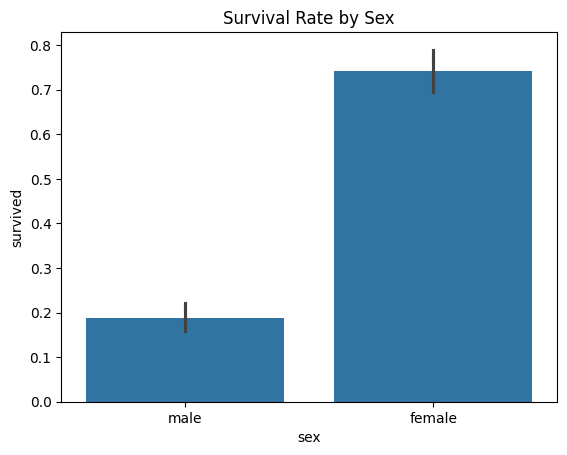

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data =  cleaneddf, x = "sex", y = "survived")
plt.title("Survival Rate by Sex")
plt.show()

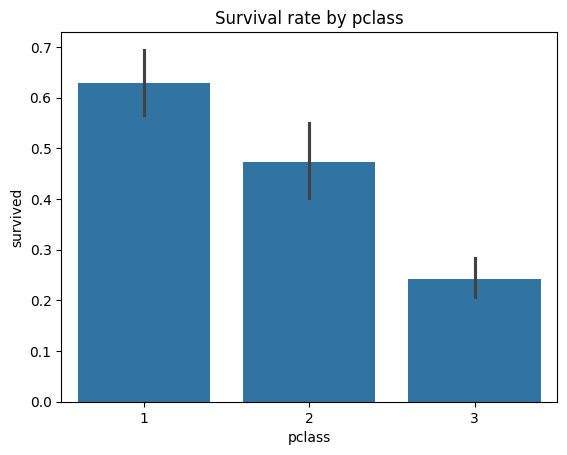

In [ ]:
sns.barplot(data = cleaneddf, x = "pclass" , y="survived")
plt.title("Survival rate by pclass")
plt.show()

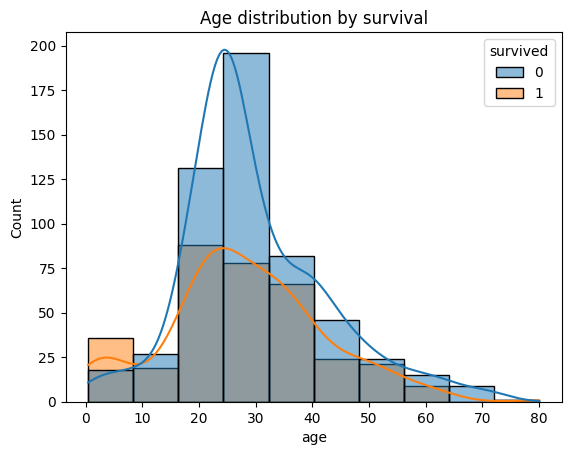

In [ ]:
sns.histplot(data = cleaneddf, x = "age", hue = "survived", kde = True, bins = 10)
plt.title("Age distribution by survival")
plt.show()

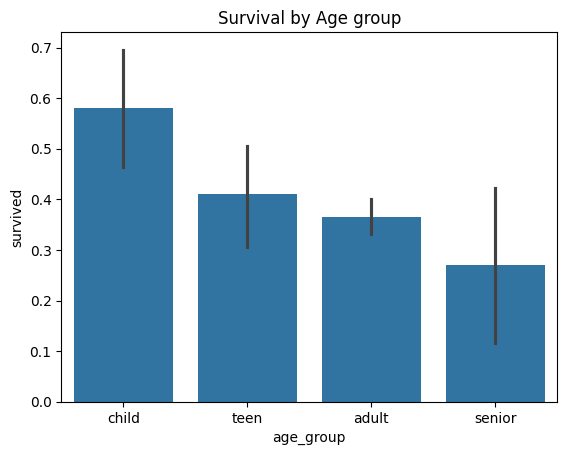

In [ ]:
sns.barplot(data = cleaneddf, x= "age_group", y = "survived")
plt.title("Survival by Age group")
plt.show()

In [ ]:
cleaneddf.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,has_cabin,title,family_size,isAlone,age_group,fare_group
0,0,3,male,22.0,1,0,7.2500,S,0,Mr,2,0,adult,low
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs,2,0,adult,very_high
2,1,3,female,26.0,0,0,7.9250,S,0,Miss,1,1,adult,meduim
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs,2,0,adult,very_high
4,0,3,male,35.0,0,0,8.0500,S,0,Mr,1,1,adult,meduim
5,0,3,male,25.0,0,0,8.4583,Q,0,Mr,1,1,adult,meduim
6,0,1,male,54.0,0,0,51.8625,S,1,Mr,1,1,adult,very_high
7,0,3,male,2.0,3,1,21.0750,S,0,Master,5,0,child,high
8,1,3,female,27.0,0,2,11.1333,S,0,Mrs,3,0,adult,meduim
9,1,2,female,14.0,1,0,30.0708,C,0,Mrs,2,0,teen,high


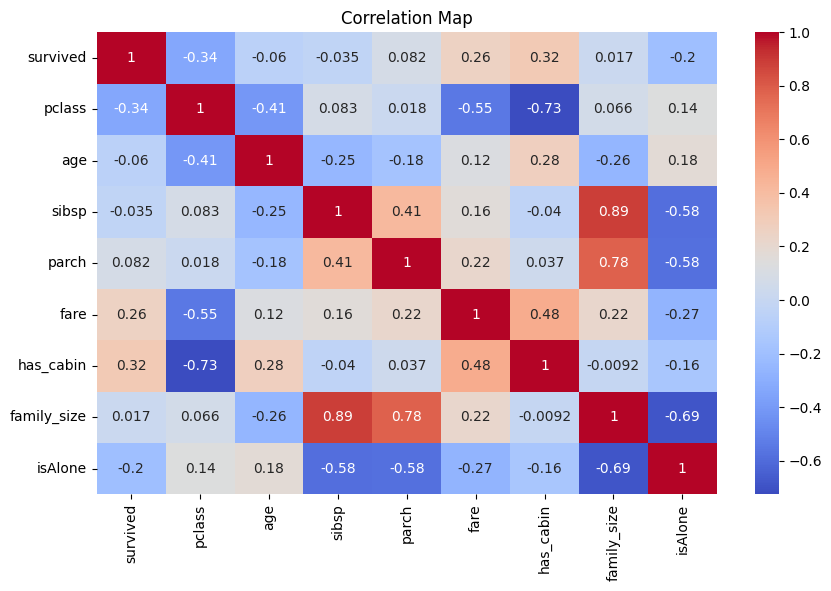

In [ ]:
#CONCEPT OF HEATMAP
#ye heatmap btayega ki hr numeric column doosre numeric column s kitna related hai aur survived factor ko konsi row sbse jyda affect kr rhi h
plt.figure(figsize=(10,6))
sns.heatmap(cleaneddf.corr(numeric_only = True), annot = True, cmap ="coolwarm")
plt.title("Correlation Map")
plt.show()

WHOLE SUMMARY OF THE DATA ANALYSIS  :
1. Amoung all the factors , sex was the strongest predictor i.e. female survival rate was 74% and male survival rate was 18%.
2. Pclass also contibutes as a strong predictor , as the people having 1st class have survival rate 63% and the ones with third class have survival rate 24%.
3. While analysing the factor Age , we saw that the rate of survival of children was the max amoung everyone which is 57% and the rate of survival of seniors was the minimun which was 26%.
4. Fare and Embarked turned out to be proxies for Pclass, rather than independent factors — their patterns were largely explained by their correlation with passenger class.
5. The effect of IsAlone diminished when analyzed within each Sex group — suggesting Sex was the dominant underlying factor, and being alone was not an independent predictor of survival on its own.